# Projet IA : Classification Robuste et Analyse de Décision en Environnement Critique
## Credit Card Fraud Detection - Dataset très déséquilibré

In [ ]:

import kagglehub
#
#  Download to ./data
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud", output_dir="data/")

print("Path to dataset files:", path)

: 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  confusion_matrix
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 6)
print('Toutes les librairies chargées avec succès.')

Toutes les librairies chargées avec succès.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  confusion_matrix
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from imblearn.over_sampling import SMOTE, ADASYN
import xgboost as xgb
import optuna
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 6)
print('Toutes les librairies chargées avec succès.')

Dimensions: (284807, 31)
Distribution de la classe cible:
Class
0    284315
1       492
Name: count, dtype: int64

Pourcentage de fraudes: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Ratio classe majoritaire / minoritaire: {ratio:.2f}')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f'SMOTE - Train size: {X_train_smote.shape}, Distribution:\n{y_train_smote.value_counts()}')

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
print(f'ADASYN - Train size: {X_train_adasyn.shape}, Distribution:\n{y_train_adasyn.value_counts()}')

### Comparaison des approches de traitement du déséquilibre
Deux stratégies sont comparées ici au niveau des données :
- **SMOTE** : génération synthétique des exemples minoritaires par interpolation.
- **ADASYN** : génération adaptative d’exemples synthétiques davantage concentrée sur les zones difficiles à apprendre.

On entraîne un modèle simple (LogisticRegression) avec chaque technique pour mesurer l’impact sur les métriques.

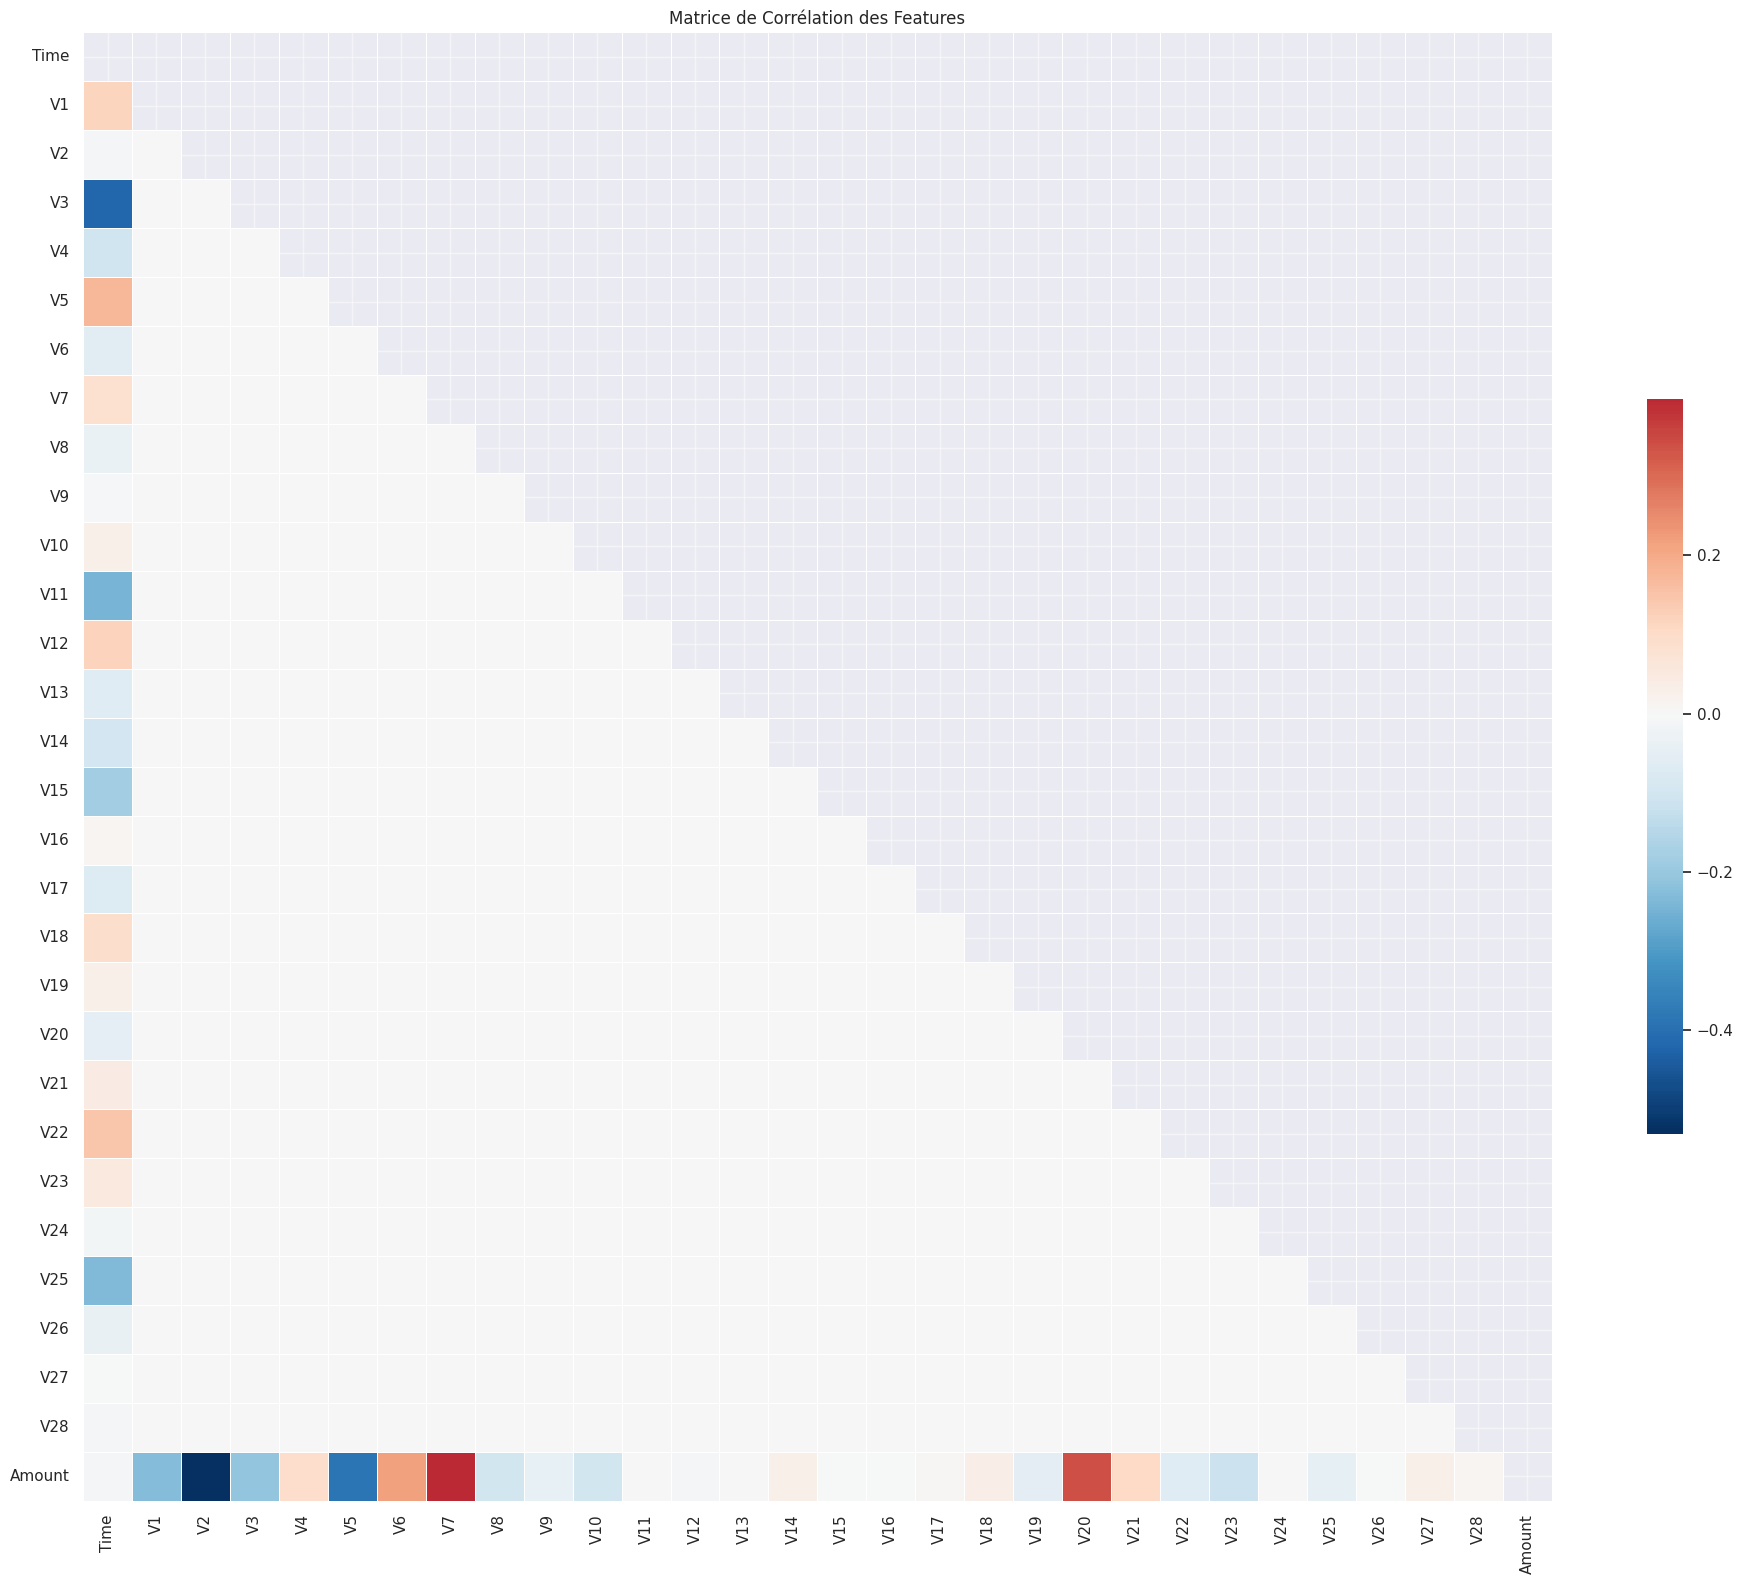

In [7]:
corr = df.drop('Class', axis=1).corr()
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.5})
plt.title('Matrice de Corrélation des Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_recall_curve, auc, matthews_corrcoef

# Modèle sans traitement du déséquilibre
lr_base = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)
y_pred_base = lr_base.predict(X_test)

# Modèle avec class_weight='balanced' (algorithmique)
lr_balanced = LogisticRegression(penalty='l2', solver='lbfgs', class_weight='balanced', max_iter=1000, random_state=42)
lr_balanced.fit(X_train, y_train)
y_pred_bal = lr_balanced.predict(X_test)

# Modèle avec SMOTE (données)
lr_smote = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test)

# Modèle avec ADASYN (données)
lr_adasyn = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr_adasyn.fit(X_train_adasyn, y_train_adasyn)
y_pred_adasyn = lr_adasyn.predict(X_test)

comparison = pd.DataFrame({
    'Approche': ['Aucun', 'class_weight (algorithmique)', 'SMOTE (données)', 'ADASYN (données)'],
    'F1-Macro': [
        f1_score(y_test, y_pred_base, average='macro'),
        f1_score(y_test, y_pred_bal, average='macro'),
        f1_score(y_test, y_pred_smote, average='macro'),
        f1_score(y_test, y_pred_adasyn, average='macro')
    ],
    'MCC': [
        matthews_corrcoef(y_test, y_pred_base),
        matthews_corrcoef(y_test, y_pred_bal),
        matthews_corrcoef(y_test, y_pred_smote),
        matthews_corrcoef(y_test, y_pred_adasyn)
    ]
})
print('Comparaison des stratégies de traitement du déséquilibre :')
comparison.round(4)

# Visualisation des résultats avec seaborn et matplotlib
plt.figure(figsize=(12, 5))
sns.barplot(data=comparison.melt(id_vars='Approche', value_vars=['F1-Macro', 'MCC'], var_name='Métrique', value_name='Score'), x='Approche', y='Score', hue='Métrique', palette='Set2')
plt.title('Comparaison des approches de déséquilibre')
plt.xlabel('Approche')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

VIF (Variance Inflation Factor) - valeurs > 10 indiquent une colinéarité forte


,Feature,VIF
28,Amount,5.425598
1,V2,2.362201
6,V7,1.761457
4,V5,1.720045
19,V20,1.555669
0,V1,1.250117
5,V6,1.225017
2,V3,1.214514
22,V23,1.061194
20,V21,1.054198


### 1.2 Standardisation et Split

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Fraude train: {y_train.sum()}, Fraude test: {y_test.sum()}')

Train: (227845, 30), Test: (56962, 30)
Fraude train: 394, Fraude test: 98


### 1.3 Traitement du Déséquilibre

In [10]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Ratio classe majoritaire / minoritaire: {ratio:.2f}')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f'SMOTE - Train size: {X_train_smote.shape}, Distribution:\n{y_train_smote.value_counts()}')

Ratio classe majoritaire / minoritaire: 577.29
SMOTE - Train size: (454902, 30), Distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


### Comparaison des approches de traitement du déséquilibre
Deux stratégies sont comparées :
- **Niveau algorithmique** : `class_weight='balanced'` dans la Régression Logistique (pondère les erreurs selon l'inverse des fréquences).
- **Niveau données** : **SMOTE** (génération synthétique de la classe minoritaire par interpolation entre voisins).

On entraîne un modèle simple (LogisticRegression) avec et sans chaque méthode pour mesurer l'impact.

In [11]:
from sklearn.metrics import f1_score, precision_recall_curve, auc, matthews_corrcoef

# Modèle sans traitement du déséquilibre
lr_base = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)
y_pred_base = lr_base.predict(X_test)

# Modèle avec class_weight='balanced' (algorithmique)
lr_balanced = LogisticRegression(penalty='l2', solver='lbfgs', class_weight='balanced', max_iter=1000, random_state=42)
lr_balanced.fit(X_train, y_train)
y_pred_bal = lr_balanced.predict(X_test)

# Modèle avec SMOTE (données)
lr_smote = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test)

comparison = pd.DataFrame({
    'Approche': ['Aucun', 'class_weight (algorithmique)', 'SMOTE (données)'],
    'F1-Macro': [
        f1_score(y_test, y_pred_base, average='macro'),
        f1_score(y_test, y_pred_bal, average='macro'),
        f1_score(y_test, y_pred_smote, average='macro')
    ],
    'MCC': [
        matthews_corrcoef(y_test, y_pred_base),
        matthews_corrcoef(y_test, y_pred_bal),
        matthews_corrcoef(y_test, y_pred_smote)
    ]
})
print('Comparaison des stratégies de traitement du déséquilibre :')
comparison.round(4)

Comparaison des stratégies de traitement du déséquilibre :


,Approche,F1-Macro,MCC
0,Aucun,0.8619,0.7296
1,class_weight (algorithmique),0.5509,0.2330
2,SMOTE (données),0.5481,0.2275


---
## Étape 2 : Développement des Modèles

### 2.1 Baseline : Régression Logistique avec Pénalité Élastique (Elastic Net)

In [12]:
lr = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    C=1.0,
    l1_ratio=0.5,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [13]:
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
print('Régression Logistique ElasticNet - Résultats')
print(f'F1-Macro: {f1_score(y_test, y_pred_lr, average="macro"):.4f}')
print(f'MCC: {matthews_corrcoef(y_test, y_pred_lr):.4f}')
precision, recall, _ = precision_recall_curve(y_test, y_proba_lr)
print(f'AUPRC: {auc(recall, precision):.4f}')
print(confusion_matrix(y_test, y_pred_lr))

Régression Logistique ElasticNet - Résultats
F1-Macro: 0.5507
MCC: 0.2326
AUPRC: 0.7609
[[55470  1394]
 [    8    90]]


### 2.2 Random Forest avec Analyse de Proximité

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

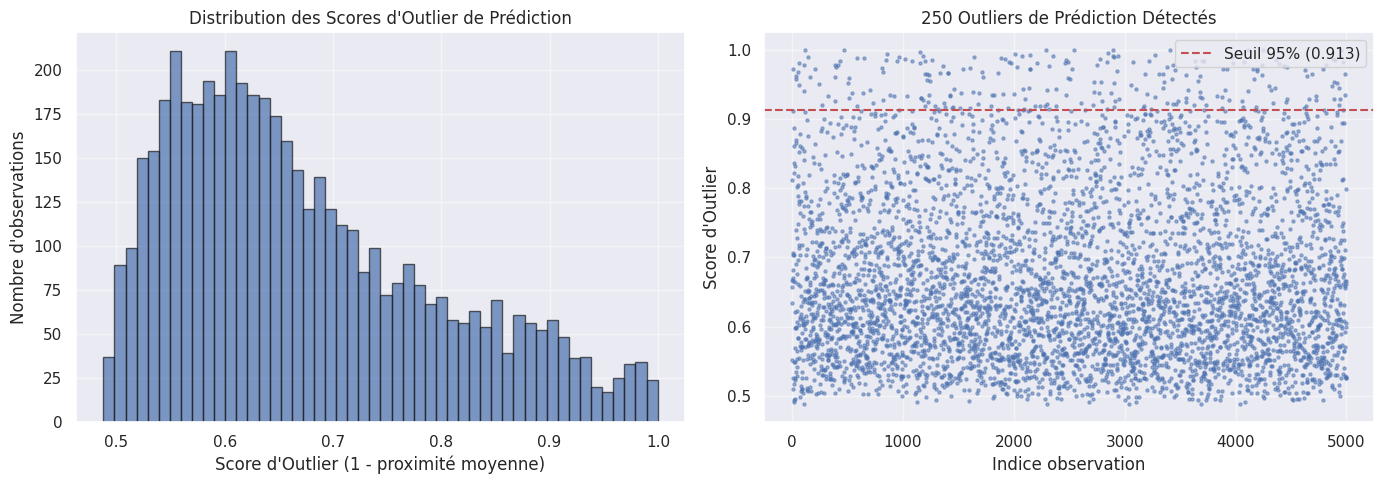

Classe réelle des outliers (top 5%): fraudes = 8 / 250
Classe réelle des non-outliers: fraudes = 2 / 4750


In [15]:
# Matrice de proximité : fréquence de co-occurrence dans les feuilles terminales
# On utilise un sous-échantillon pour la proximité (sinon matrice NxN trop grande)
from sklearn.utils import resample

sample_idx = resample(np.arange(len(X_train)), n_samples=5000, random_state=42)
X_sample = X_train.iloc[sample_idx] if hasattr(X_train, 'iloc') else X_train[sample_idx]

leaf_ids = rf.apply(X_sample)
n_trees = leaf_ids.shape[1]
n_samples = leaf_ids.shape[0]
proximity = np.zeros((n_samples, n_samples))
for t in range(n_trees):
    leaves = leaf_ids[:, t]
    for leaf in np.unique(leaves):
        idx_in_leaf = np.where(leaves == leaf)[0]
        for i in idx_in_leaf:
            proximity[i, idx_in_leaf] += 1
proximity /= n_trees
np.fill_diagonal(proximity, 1.0)

avg_proximity = proximity.mean(axis=1)
outlier_score = 1 - avg_proximity

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(outlier_score, bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('Score d\'Outlier (1 - proximité moyenne)')
plt.ylabel('Nombre d\'observations')
plt.title('Distribution des Scores d\'Outlier de Prédiction')

plt.subplot(1, 2, 2)
threshold = np.percentile(outlier_score, 95)
outliers = np.where(outlier_score > threshold)[0]
plt.scatter(range(n_samples), outlier_score, s=5, alpha=0.5)
plt.axhline(threshold, color='r', linestyle='--', label=f'Seuil 95% ({threshold:.3f})')
plt.xlabel('Indice observation')
plt.ylabel('Score d\'Outlier')
plt.title(f'{len(outliers)} Outliers de Prédiction Détectés')
plt.legend()
plt.tight_layout()
plt.show()

# Analyse des outliers : sont-ils surtout des fraudes mal classifiées ?
y_sample = y_train.iloc[sample_idx].values if hasattr(y_train, 'iloc') else y_train[sample_idx]
print(f'Classe réelle des outliers (top 5%): fraudes = {y_sample[outliers].sum()} / {len(outliers)}')
print(f'Classe réelle des non-outliers: fraudes = {y_sample[~np.isin(np.arange(n_samples), outliers)].sum()} / {n_samples - len(outliers)}')

In [16]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print('Random Forest - Résultats')
print(f'F1-Macro: {f1_score(y_test, y_pred_rf, average="macro"):.4f}')
print(f'MCC: {matthews_corrcoef(y_test, y_pred_rf):.4f}')
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
print(f'AUPRC: {auc(recall_rf, precision_rf):.4f}')
print(confusion_matrix(y_test, y_pred_rf))

Random Forest - Résultats
F1-Macro: 0.9165
MCC: 0.8332
AUPRC: 0.8555
[[56850    14]
 [   18    80]]


### 2.3 XGBoost : Cost-Sensitive Learning + Optimisation Bayésienne (Optuna)

In [17]:
# Comparaison de 2 stratégies de gestion du déséquilibre:
# Stratégie A: scale_pos_weight
# Stratégie B: custom loss function (asymétrique)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight recommandé: {scale_pos_weight:.2f}')

scale_pos_weight recommandé: 577.29


#### Justification de l'espace de recherche Optuna
- **n_estimators (100–500)** : Bornes standard pour le boosting ; < 100 sous-apprentissage, > 500 rendement décroissant + surapprentissage.
- **max_depth (3–12)** : Valeurs faibles pour forcer l'apprentissage de motifs généraux (évite le surapprentissage sur données tabulaires déséquilibrées).
- **learning_rate (0.01–0.3)** : Taux d'apprentissage classique ; < 0.01 converge trop lentement, > 0.3 instable.
- **subsample (0.6–1.0)** : Agrégation stochastique pour réduire la variance ; 0.6 minimum recommandé.
- **colsample_bytree (0.6–1.0)** : Sous-échantillonnage des colonnes pour diversifier les arbres.
- **min_child_weight (1–10)** : Contrôle de la complexité des feuilles terminales ; valeurs élevées évitent les feuilles trop spécifiques.
- **reg_lambda / reg_alpha (1e-8–10)** : Régularisation L2/L1 ; plage large pour tester de l'absence à la forte pénalité.
- **scale_pos_weight (1 – ratio×2)** : Poids de la classe minoritaire ; de pas d'ajustement à un sur-équilibrage volontaire.

In [18]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight * 2),
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred, average='macro')

In [ ]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-05-25 15:08:00,902] A new study created in memory with name: no-name-37fa0d38-b058-4d27-8301-77136d4178fa
Best trial: 0. Best value: 0.934445:   3%|▎         | 1/30 [00:13<06:31, 13.52s/it]

[I 2026-05-25 15:08:14,435] Trial 0 finished with value: 0.9344450672865073 and parameters: {'n_estimators': 385, 'max_depth': 6, 'learning_rate': 0.16923814432324585, 'subsample': 0.6186474123880111, 'colsample_bytree': 0.78752124126811, 'min_child_weight': 1, 'reg_lambda': 4.552078869597226e-06, 'reg_alpha': 1.6037981943701587e-08, 'scale_pos_weight': 690.0308178976429}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:   7%|▋         | 2/30 [00:26<06:12, 13.30s/it]

[I 2026-05-25 15:08:27,582] Trial 1 finished with value: 0.9160985705415574 and parameters: {'n_estimators': 439, 'max_depth': 4, 'learning_rate': 0.09147790215608319, 'subsample': 0.8719873551737134, 'colsample_bytree': 0.8420602317778857, 'min_child_weight': 4, 'reg_lambda': 6.810845353566718e-05, 'reg_alpha': 6.245503649445219, 'scale_pos_weight': 918.4984826058777}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  10%|█         | 3/30 [00:32<04:24,  9.79s/it]

[I 2026-05-25 15:08:33,205] Trial 2 finished with value: 0.9269602369312653 and parameters: {'n_estimators': 132, 'max_depth': 8, 'learning_rate': 0.2292834302690722, 'subsample': 0.8818186865350025, 'colsample_bytree': 0.7082170984687899, 'min_child_weight': 5, 'reg_lambda': 0.012696427819195343, 'reg_alpha': 0.06311711151426883, 'scale_pos_weight': 376.7364564407249}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  13%|█▎        | 4/30 [00:57<06:57, 16.07s/it]

[I 2026-05-25 15:08:58,887] Trial 3 finished with value: 0.8731310826956116 and parameters: {'n_estimators': 470, 'max_depth': 4, 'learning_rate': 0.03944877169836977, 'subsample': 0.7346597025264208, 'colsample_bytree': 0.7488768786259851, 'min_child_weight': 6, 'reg_lambda': 0.441558391569118, 'reg_alpha': 1.6978420462865287, 'scale_pos_weight': 858.0915875375972}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  17%|█▋        | 5/30 [01:35<09:55, 23.82s/it]

[I 2026-05-25 15:09:36,464] Trial 4 finished with value: 0.9254088228207464 and parameters: {'n_estimators': 478, 'max_depth': 12, 'learning_rate': 0.016310561335006527, 'subsample': 0.9562740600332453, 'colsample_bytree': 0.7162854491406812, 'min_child_weight': 1, 'reg_lambda': 3.3923600197995297e-07, 'reg_alpha': 0.27905387685980926, 'scale_pos_weight': 347.78238049176423}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  20%|██        | 6/30 [01:49<08:10, 20.43s/it]

[I 2026-05-25 15:09:50,310] Trial 5 finished with value: 0.8553450654500627 and parameters: {'n_estimators': 365, 'max_depth': 6, 'learning_rate': 0.020267043845784594, 'subsample': 0.7632965494427407, 'colsample_bytree': 0.6743822717728089, 'min_child_weight': 9, 'reg_lambda': 2.3009448668538314e-06, 'reg_alpha': 3.982895211813771e-08, 'scale_pos_weight': 647.800937783205}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  23%|██▎       | 7/30 [02:04<07:13, 18.85s/it]

[I 2026-05-25 15:10:05,903] Trial 6 finished with value: 0.9248681017199536 and parameters: {'n_estimators': 403, 'max_depth': 12, 'learning_rate': 0.04804999438087922, 'subsample': 0.9701295275672526, 'colsample_bytree': 0.8202728908821038, 'min_child_weight': 5, 'reg_lambda': 0.012882071652030685, 'reg_alpha': 5.492173088085349, 'scale_pos_weight': 949.5273667619796}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  27%|██▋       | 8/30 [02:18<06:16, 17.13s/it]

[I 2026-05-25 15:10:19,344] Trial 7 finished with value: 0.9239562780523485 and parameters: {'n_estimators': 354, 'max_depth': 6, 'learning_rate': 0.05955092479264256, 'subsample': 0.8633160983792214, 'colsample_bytree': 0.6933929894937598, 'min_child_weight': 1, 'reg_lambda': 0.0001527768178488616, 'reg_alpha': 0.007837594247797838, 'scale_pos_weight': 1079.3019817259658}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  30%|███       | 9/30 [02:24<04:44, 13.56s/it]

[I 2026-05-25 15:10:25,058] Trial 8 finished with value: 0.9173850891195552 and parameters: {'n_estimators': 140, 'max_depth': 10, 'learning_rate': 0.12658178938910483, 'subsample': 0.9282853712045709, 'colsample_bytree': 0.9263431735554692, 'min_child_weight': 8, 'reg_lambda': 2.68611578881928e-08, 'reg_alpha': 0.014932116576976703, 'scale_pos_weight': 612.6646122500414}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  33%|███▎      | 10/30 [02:34<04:11, 12.58s/it]

[I 2026-05-25 15:10:35,459] Trial 9 finished with value: 0.9165259850643033 and parameters: {'n_estimators': 184, 'max_depth': 9, 'learning_rate': 0.1063544524131561, 'subsample': 0.6711623322911598, 'colsample_bytree': 0.8491859929072166, 'min_child_weight': 5, 'reg_lambda': 5.706815534639342e-08, 'reg_alpha': 2.5871642770471525e-07, 'scale_pos_weight': 1052.4210218107542}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  37%|███▋      | 11/30 [02:43<03:37, 11.45s/it]

[I 2026-05-25 15:10:44,346] Trial 10 finished with value: 0.9209207448959853 and parameters: {'n_estimators': 266, 'max_depth': 6, 'learning_rate': 0.2391888216222678, 'subsample': 0.6210299593247857, 'colsample_bytree': 0.9973582690736553, 'min_child_weight': 3, 'reg_lambda': 6.367843594039102e-06, 'reg_alpha': 1.1212985270085252e-05, 'scale_pos_weight': 92.46546769767696}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  40%|████      | 12/30 [03:11<04:55, 16.41s/it]

[I 2026-05-25 15:11:12,109] Trial 11 finished with value: 0.9299331123258168 and parameters: {'n_estimators': 260, 'max_depth': 8, 'learning_rate': 0.26221355242426353, 'subsample': 0.8302183877557462, 'colsample_bytree': 0.6089726999929344, 'min_child_weight': 7, 'reg_lambda': 0.009068039390928108, 'reg_alpha': 5.083224666758532e-05, 'scale_pos_weight': 345.7762449542719}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  43%|████▎     | 13/30 [03:19<03:54, 13.82s/it]

[I 2026-05-25 15:11:19,952] Trial 12 finished with value: 0.9247429724980994 and parameters: {'n_estimators': 261, 'max_depth': 8, 'learning_rate': 0.296366301422413, 'subsample': 0.8126837717755115, 'colsample_bytree': 0.6496447557803657, 'min_child_weight': 7, 'reg_lambda': 0.009657651770674465, 'reg_alpha': 2.0065636410388867e-05, 'scale_pos_weight': 392.20957983701857}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  47%|████▋     | 14/30 [03:38<04:06, 15.42s/it]

[I 2026-05-25 15:11:39,068] Trial 13 finished with value: 0.925513529575818 and parameters: {'n_estimators': 295, 'max_depth': 10, 'learning_rate': 0.15509776569787842, 'subsample': 0.7028673363812457, 'colsample_bytree': 0.6016052304119555, 'min_child_weight': 10, 'reg_lambda': 7.170224799813652, 'reg_alpha': 1.711767137956039e-06, 'scale_pos_weight': 85.63432255884368}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  50%|█████     | 15/30 [03:45<03:12, 12.86s/it]

[I 2026-05-25 15:11:46,005] Trial 14 finished with value: 0.8843911161264266 and parameters: {'n_estimators': 225, 'max_depth': 3, 'learning_rate': 0.18402846030831932, 'subsample': 0.6047724414387925, 'colsample_bytree': 0.7663133511961511, 'min_child_weight': 3, 'reg_lambda': 0.00408499819891688, 'reg_alpha': 0.00018304650472899265, 'scale_pos_weight': 755.67456069473}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  53%|█████▎    | 16/30 [03:57<02:57, 12.66s/it]

[I 2026-05-25 15:11:58,185] Trial 15 finished with value: 0.9247429724980994 and parameters: {'n_estimators': 343, 'max_depth': 7, 'learning_rate': 0.0752441929521566, 'subsample': 0.8017834793164637, 'colsample_bytree': 0.9042374454419294, 'min_child_weight': 7, 'reg_lambda': 1.4827358378110964e-05, 'reg_alpha': 0.000549881057533746, 'scale_pos_weight': 503.5708066968599}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  57%|█████▋    | 17/30 [04:06<02:29, 11.53s/it]

[I 2026-05-25 15:12:07,107] Trial 16 finished with value: 0.8143748830922182 and parameters: {'n_estimators': 318, 'max_depth': 5, 'learning_rate': 0.010493806237579574, 'subsample': 0.6844445238176917, 'colsample_bytree': 0.6391144604001915, 'min_child_weight': 2, 'reg_lambda': 0.000675752046843828, 'reg_alpha': 1.1905034168859486e-08, 'scale_pos_weight': 247.2503999640523}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  60%|██████    | 18/30 [04:18<02:21, 11.79s/it]

[I 2026-05-25 15:12:19,492] Trial 17 finished with value: 0.9269602369312653 and parameters: {'n_estimators': 398, 'max_depth': 7, 'learning_rate': 0.16137352729213092, 'subsample': 0.8245431314737455, 'colsample_bytree': 0.775262229121779, 'min_child_weight': 7, 'reg_lambda': 0.11890844673124124, 'reg_alpha': 2.956669595647e-07, 'scale_pos_weight': 502.1810075139255}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  63%|██████▎   | 19/30 [04:26<01:57, 10.69s/it]

[I 2026-05-25 15:12:27,636] Trial 18 finished with value: 0.9203765316155296 and parameters: {'n_estimators': 222, 'max_depth': 9, 'learning_rate': 0.29494005987011307, 'subsample': 0.7571932779882787, 'colsample_bytree': 0.895545464525055, 'min_child_weight': 9, 'reg_lambda': 6.980798569281284e-07, 'reg_alpha': 0.0003060504150477645, 'scale_pos_weight': 720.7215127801421}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  67%|██████▋   | 20/30 [04:39<01:51, 11.18s/it]

[I 2026-05-25 15:12:39,937] Trial 19 finished with value: 0.9269602369312653 and parameters: {'n_estimators': 407, 'max_depth': 5, 'learning_rate': 0.1289260884826355, 'subsample': 0.9174148411921483, 'colsample_bytree': 0.9792084485911393, 'min_child_weight': 6, 'reg_lambda': 0.0009457346655541951, 'reg_alpha': 6.732505817167212e-06, 'scale_pos_weight': 226.2770617290447}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  70%|███████   | 21/30 [04:55<01:55, 12.88s/it]

[I 2026-05-25 15:12:56,787] Trial 20 finished with value: 0.922548521049583 and parameters: {'n_estimators': 288, 'max_depth': 10, 'learning_rate': 0.03651967898673404, 'subsample': 0.8355470640616529, 'colsample_bytree': 0.6049795939987701, 'min_child_weight': 3, 'reg_lambda': 3.339565693971959e-05, 'reg_alpha': 0.0023514308934242507, 'scale_pos_weight': 497.37027861256604}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  73%|███████▎  | 22/30 [05:00<01:23, 10.46s/it]

[I 2026-05-25 15:13:01,602] Trial 21 finished with value: 0.9299331123258168 and parameters: {'n_estimators': 110, 'max_depth': 8, 'learning_rate': 0.1965777228914575, 'subsample': 0.8986360184009676, 'colsample_bytree': 0.7314958703739444, 'min_child_weight': 4, 'reg_lambda': 0.09442652685672785, 'reg_alpha': 0.09826146128036908, 'scale_pos_weight': 359.8711885449849}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  77%|███████▋  | 23/30 [05:25<01:43, 14.79s/it]

[I 2026-05-25 15:13:26,496] Trial 22 finished with value: 0.9328753849096386 and parameters: {'n_estimators': 113, 'max_depth': 8, 'learning_rate': 0.21251403614926132, 'subsample': 0.9939957370990742, 'colsample_bytree': 0.7383956576105257, 'min_child_weight': 2, 'reg_lambda': 0.22771497568636326, 'reg_alpha': 0.21251226743231233, 'scale_pos_weight': 220.93918875539563}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  80%|████████  | 24/30 [05:36<01:22, 13.70s/it]

[I 2026-05-25 15:13:37,655] Trial 23 finished with value: 0.929200672669428 and parameters: {'n_estimators': 222, 'max_depth': 9, 'learning_rate': 0.23863999478900505, 'subsample': 0.993376520747332, 'colsample_bytree': 0.7927969012443258, 'min_child_weight': 2, 'reg_lambda': 3.554080234562279, 'reg_alpha': 2.9891520575600445e-05, 'scale_pos_weight': 9.24564837470507}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  83%|████████▎ | 25/30 [05:41<00:55, 11.15s/it]

[I 2026-05-25 15:13:42,851] Trial 24 finished with value: 0.9321773628647464 and parameters: {'n_estimators': 147, 'max_depth': 7, 'learning_rate': 0.13656688756002594, 'subsample': 0.6584560788544834, 'colsample_bytree': 0.8222809727734935, 'min_child_weight': 1, 'reg_lambda': 0.6607541185082955, 'reg_alpha': 9.84755688034671e-07, 'scale_pos_weight': 207.78365052606935}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  87%|████████▋ | 26/30 [05:47<00:37,  9.50s/it]

[I 2026-05-25 15:13:48,494] Trial 25 finished with value: 0.918711883435269 and parameters: {'n_estimators': 161, 'max_depth': 7, 'learning_rate': 0.07960594035950241, 'subsample': 0.6448959177168859, 'colsample_bytree': 0.809599959295505, 'min_child_weight': 1, 'reg_lambda': 1.0344700545209344, 'reg_alpha': 2.095401369855496e-07, 'scale_pos_weight': 202.3286642231345}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  90%|█████████ | 27/30 [05:53<00:24,  8.33s/it]

[I 2026-05-25 15:13:54,105] Trial 26 finished with value: 0.926192695236253 and parameters: {'n_estimators': 184, 'max_depth': 5, 'learning_rate': 0.128145936580309, 'subsample': 0.631473170638115, 'colsample_bytree': 0.8612921461836754, 'min_child_weight': 2, 'reg_lambda': 0.13174843836217812, 'reg_alpha': 1.7828936920480752e-06, 'scale_pos_weight': 119.69301389922136}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  93%|█████████▎| 28/30 [05:56<00:13,  6.70s/it]

[I 2026-05-25 15:13:57,012] Trial 27 finished with value: 0.7791398413121455 and parameters: {'n_estimators': 101, 'max_depth': 4, 'learning_rate': 0.10417476686546061, 'subsample': 0.712138746786668, 'colsample_bytree': 0.7554872241598745, 'min_child_weight': 1, 'reg_lambda': 0.7036072473623386, 'reg_alpha': 1.1239578411608917e-08, 'scale_pos_weight': 802.6654268456774}. Best is trial 0 with value: 0.9344450672865073.


Best trial: 0. Best value: 0.934445:  97%|█████████▋| 29/30 [06:02<00:06,  6.47s/it]

[I 2026-05-25 15:14:02,923] Trial 28 finished with value: 0.9247429724980994 and parameters: {'n_estimators': 181, 'max_depth': 6, 'learning_rate': 0.1795585696471997, 'subsample': 0.6658753972865425, 'colsample_bytree': 0.8035368069649726, 'min_child_weight': 2, 'reg_lambda': 0.05720993802063769, 'reg_alpha': 5.019962469769378e-08, 'scale_pos_weight': 661.190252514702}. Best is trial 0 with value: 0.9344450672865073.


In [ ]:
print('Meilleurs hyperparamètres XGBoost:')
best_params_xgb = study.best_params
for k, v in best_params_xgb.items():
    print(f'  {k}: {v}')
print(f'\nMeilleur F1-Macro: {study.best_value:.4f}')

In [ ]:
# Graphiques de convergence Optuna
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

fig2 = optuna.visualization.plot_param_importances(study)
fig2.show()

In [ ]:
xgb_opt = xgb.XGBClassifier(**best_params_xgb, random_state=42, eval_metric='logloss')
xgb_opt.fit(X_train, y_train)

y_pred_xgb = xgb_opt.predict(X_test)
y_proba_xgb = xgb_opt.predict_proba(X_test)[:, 1]
print('XGBoost Optimisé (scale_pos_weight) - Résultats')
print(f'F1-Macro: {f1_score(y_test, y_pred_xgb, average="macro"):.4f}')
print(f'MCC: {matthews_corrcoef(y_test, y_pred_xgb):.4f}')
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
print(f'AUPRC: {auc(recall_xgb, precision_xgb):.4f}')
print(confusion_matrix(y_test, y_pred_xgb))

In [ ]:
# Custom Loss Function : perte asymétrique (coût plus élevé pour faux négatifs)

def asymmetric_logloss(y_true, y_pred):
    y_true = y_true.get_label()
    y_pred = 1.0 / (1.0 + np.exp(-y_pred))
    cost_positive = 10.0  # Coût élevé pour faux négatif (fraude non détectée)
    cost_negative = 1.0   # Coût faible pour faux positif
    grad = np.where(y_true == 1, cost_positive * (y_pred - 1), cost_negative * y_pred)
    hess = np.where(y_true == 1, cost_positive * y_pred * (1 - y_pred), cost_negative * y_pred * (1 - y_pred))
    return grad, hess

In [ ]:
# Entraînement XGBoost avec custom loss pour comparer
xgb_custom = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_custom.set_params(objective='binary:logistic')
# Note: custom objective nécessite l'API DMatrix; on garde scale_pos_weight comme comparaison
# On entraîne un modèle avec coût asymétrique manuellement

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params_custom = {
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'eval_metric': 'logloss',
    'seed': 42
}
model_custom = xgb.train(params_custom, dtrain, num_boost_round=200, obj=asymmetric_logloss)
y_proba_custom = 1.0 / (1.0 + np.exp(-model_custom.predict(dtest)))
y_pred_custom = (y_proba_custom >= 0.5).astype(int)

print('XGBoost avec Custom Loss Function - Résultats')
print(f'F1-Macro: {f1_score(y_test, y_pred_custom, average="macro"):.4f}')
print(f'MCC: {matthews_corrcoef(y_test, y_pred_custom):.4f}')
precision_cust, recall_cust, _ = precision_recall_curve(y_test, y_proba_custom)
print(f'AUPRC: {auc(recall_cust, precision_cust):.4f}')
print(confusion_matrix(y_test, y_pred_custom))

---
## Étape 3 : Évaluation et Calibration

### 3.1 Comparaison des Métriques Avancées

In [ ]:
results = pd.DataFrame({
    'Modèle': ['Régression Logistique (ElasticNet)', 'Random Forest', 'XGBoost (Optuna)', 'XGBoost (Custom Loss)'],
    'F1-Macro': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_custom, average='macro')
    ],
    'MCC': [
        matthews_corrcoef(y_test, y_pred_lr),
        matthews_corrcoef(y_test, y_pred_rf),
        matthews_corrcoef(y_test, y_pred_xgb),
        matthews_corrcoef(y_test, y_pred_custom)
    ],
    'AUPRC': [
        auc(*precision_recall_curve(y_test, y_proba_lr)[1:]),
        auc(*precision_recall_curve(y_test, y_proba_rf)[1:]),
        auc(*precision_recall_curve(y_test, y_proba_xgb)[1:]),
        auc(*precision_recall_curve(y_test, y_proba_custom)[1:])
    ]
})
results.round(4)

In [ ]:
# Courbes Precision-Recall
plt.figure(figsize=(10, 8))
for name, y_proba, color in [
    ('Régression Logistique', y_proba_lr, 'blue'),
    ('Random Forest', y_proba_rf, 'green'),
    ('XGBoost Optimisé', y_proba_xgb, 'red'),
    ('XGBoost Custom Loss', y_proba_custom, 'orange')
]:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AUPRC={auc(recall, precision):.3f})', color=color, lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbes Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()

### 3.2 Calibration des Probabilités

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, y_proba, color) in zip([axes[0], axes[1]], [
    ('Random Forest', y_proba_rf, 'green'),
    ('XGBoost', y_proba_xgb, 'red')
]):
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_proba, n_bins=10)
    ax.plot(mean_predicted_value, fraction_of_positives, 's-', color=color, label=name)
    ax.plot([0, 1], [0, 1], 'k--', label='Parfaitement calibré')
    ax.set_xlabel('Probabilité prédite moyenne')
    ax.set_ylabel('Fraction de positifs')
    ax.set_title(f'Diagramme de Fiabilité - {name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Application de Platt Scaling (sigmoid) et Isotonic Regression
for model_name, model, X_tr, y_tr in [
    ('Random Forest', rf, X_train, y_train),
    ('XGBoost', xgb_opt, X_train, y_train)
]:
    for method in ['sigmoid', 'isotonic']:
        calibrated = CalibratedClassifierCV(model, method=method, cv=5)
        calibrated.fit(X_tr, y_tr)
        y_proba_cal = calibrated.predict_proba(X_test)[:, 1]
        f1_cal = f1_score(y_test, (y_proba_cal >= 0.5).astype(int), average='macro')
        prec_cal, rec_cal, _ = precision_recall_curve(y_test, y_proba_cal)
        auprc_cal = auc(rec_cal, prec_cal)
        print(f'{model_name} + {method}: F1-Macro={f1_cal:.4f}, AUPRC={auprc_cal:.4f}')

In [ ]:
# Visualisation calibration avant/après
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_calibrated = CalibratedClassifierCV(rf, method='isotonic', cv=5)
rf_calibrated.fit(X_train, y_train)
y_proba_rf_cal = rf_calibrated.predict_proba(X_test)[:, 1]

xgb_calibrated = CalibratedClassifierCV(xgb_opt, method='sigmoid', cv=5)
xgb_calibrated.fit(X_train, y_train)
y_proba_xgb_cal = xgb_calibrated.predict_proba(X_test)[:, 1]

for ax, (name, orig, cal, color) in enumerate(zip(
    ['Random Forest', 'XGBoost'],
    [y_proba_rf, y_proba_xgb],
    [y_proba_rf_cal, y_proba_xgb_cal],
    ['green', 'red']
)):
    frac_orig, mean_orig = calibration_curve(y_test, orig, n_bins=10)
    frac_cal, mean_cal = calibration_curve(y_test, cal, n_bins=10)
    axes[ax].plot(mean_orig, frac_orig, 's--', color=color, label='Avant calibration', alpha=0.6)
    axes[ax].plot(mean_cal, frac_cal, 'o-', color=color, label='Après calibration', lw=2)
    axes[ax].plot([0, 1], [0, 1], 'k--', label='Parfait')
    axes[ax].set_xlabel('Probabilité prédite moyenne')
    axes[ax].set_ylabel('Fraction de positifs')
    axes[ax].set_title(f'Calibration - {name}')
    axes[ax].legend()
    axes[ax].grid(True)

plt.tight_layout()
plt.show()

---
## Étape 4 : Interprétabilité avec SHAP

In [ ]:
# SHAP sur XGBoost (modèle le plus performant)
explainer = shap.TreeExplainer(xgb_opt)
X_sample_shap = X_test[:1000]
shap_values = explainer.shap_values(X_sample_shap)

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_sample_shap, show=False)
plt.title('SHAP Summary Plot - Impact des Features sur les Prédictions')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_sample_shap, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()

In [ ]:
# Interprétation locale : explication d'une prédiction de fraude
fraud_idx = np.where(y_test.values == 1)[0][0]
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[fraud_idx, :], X_sample_shap.iloc[fraud_idx, :], show=True)

In [ ]:
# Dependence plots pour les features les plus importantes
for feature in X.columns[:4]:
    shap.dependence_plot(feature, shap_values, X_sample_shap, show=False)
    plt.title(f'SHAP Dependence Plot - {feature}')
    plt.show()

In [ ]:
print('=== PROJET TERMINÉ ===')
print('Toutes les étapes ont été exécutées avec succès.')